# ДЗ 1 -- EdgeMTSC

> Сорочан Дмитрий, ПАДИИ3

## 00. EDA

### Что делать буду?

Для эксперимента беру `UCI Human Activity Recognition Using Smartphones` -- популярный benchmark для классификации многомерных временных рядов с инерциальных датчиков смартфона.

Корпус на Hugging Face: https://huggingface.co/datasets/udayl/UCI_HAR

Оригинальное описание UCI: https://archive.ics.uci.edu/dataset/240/human+activity+recognition+using+smartphones

Почему выбрал именно его:

- в официальном split 7352 train и 2947 test окон -- данных достаточно, чтобы оценивать DL-модели не на нескольких десятках примеров;
- один объект -- 9 синхронных каналов по 128 отсчетов: body acceleration, gyroscope и total acceleration по трем осям;
- 6 классов активности, причем есть заведомо похожие пары вроде `SITTING` / `STANDING` и `WALKING_UPSTAIRS` / `WALKING_DOWNSTAIRS`;
- train/test разбиты по людям, поэтому можно честно проверить перенос на новых пользователей;
- по UCI HAR есть много опубликованных CNN/LSTM/Transformer baseline -- будет понятно, если моя модель внезапно дает совсем странный результат;
- обучаю все локально на ноуте, поэтому беру достаточно содержательный корпус, но без слишком тяжелых длинных рядов.

В качестве внешнего sanity check беру открытую реализацию на том же raw `9 x 128` input: 1D-CNN там дает `93%` test accuracy. Это не моя baseline и не строгое сравнение -- протоколы обучения отличаются.

Источник: https://github.com/healthDataScience/deep-learning-HAR


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from huggingface_hub import hf_hub_download
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

ROOT = Path("..") if Path.cwd().name == "notebooks" else Path(".")
(ROOT / "data").mkdir(exist_ok=True)
(ROOT / "figures").mkdir(exist_ok=True)

pd.set_option("display.max_rows", 100)
sns.set_theme(style="whitegrid")


### Загружаю raw inertial signals

Использую именно временные сигналы, а не готовые 561 engineered features. Иначе проверять EdgeMTSC было бы бессмысленно.


In [2]:
REPO = "udayl/UCI_HAR"
SIGNALS = [
    "body_acc_x", "body_acc_y", "body_acc_z",
    "body_gyro_x", "body_gyro_y", "body_gyro_z",
    "total_acc_x", "total_acc_y", "total_acc_z",
]
CLASS_NAMES = [
    "WALKING", "WALKING_UPSTAIRS", "WALKING_DOWNSTAIRS",
    "SITTING", "STANDING", "LAYING",
]


def load_split(split):
    suffix = "train" if split == "train" else "test"
    paths = [
        hf_hub_download(
            repo_id=REPO,
            repo_type="dataset",
            filename=f"{split}/Inertial Signals/{name}_{suffix}.txt",
        )
        for name in SIGNALS
    ]
    X = np.stack([np.loadtxt(path) for path in paths], axis=1).astype("float32")
    y = np.loadtxt(hf_hub_download(REPO, f"{split}/y_{suffix}.txt", repo_type="dataset")).astype("int64") - 1
    subjects = np.loadtxt(hf_hub_download(REPO, f"{split}/subject_{suffix}.txt", repo_type="dataset")).astype("int64")
    return X, y, subjects


X_train, y_train, subjects_train = load_split("train")
X_test, y_test, subjects_test = load_split("test")

print("train:", X_train.shape)
print("test: ", X_test.shape)
print("classes:", len(CLASS_NAMES))


train/Inertial Signals/body_acc_x_train.(…): reconstructing file:   0%|          |  0.00B / 15.1MB            

train/Inertial Signals/body_acc_x_train.(…): downloading bytes:           |  0.00B            

train/Inertial Signals/body_acc_y_train.(…): reconstructing file:   0%|          |  0.00B / 15.1MB            

train/Inertial Signals/body_acc_y_train.(…): downloading bytes:           |  0.00B            

train/Inertial Signals/body_acc_z_train.(…): reconstructing file:   0%|          |  0.00B / 15.1MB            

...

total_acc_y_test.txt:   0%|          | 0.00/6.04M [00:00<?, ?B/s]

total_acc_z_test.txt:   0%|          | 0.00/6.04M [00:00<?, ?B/s]

y_test.txt:   0%|          | 0.00/5.89k [00:00<?, ?B/s]

subject_test.txt:   0%|          | 0.00/7.93k [00:00<?, ?B/s]

train: (7352, 9, 128)
test:  (2947, 9, 128)
classes: 6


Форма массива -- `[object, channel, time]`. Получается нормальная MTSC-задача: `9` переменных наблюдаются синхронно на `128` временных шагах.


### Базовые проверки


In [3]:
checks = pd.DataFrame({
    "split": ["train", "test"],
    "objects": [len(X_train), len(X_test)],
    "nan": [np.isnan(X_train).sum(), np.isnan(X_test).sum()],
    "inf": [np.isinf(X_train).sum(), np.isinf(X_test).sum()],
    "duplicate_windows": [
        pd.DataFrame(X_train.reshape(len(X_train), -1)).duplicated().sum(),
        pd.DataFrame(X_test.reshape(len(X_test), -1)).duplicated().sum(),
    ],
    "subjects": [len(np.unique(subjects_train)), len(np.unique(subjects_test))],
})
checks


,split,objects,nan,inf,duplicate_windows,subjects
0,train,7352,0,0,0,21
1,test,2947,0,0,0,9


In [4]:
print("общих subjects в train/test:", np.intersect1d(subjects_train, subjects_test))


общих subjects в train/test: []


Official split действительно subject-independent -- train и test не содержат общих людей. Сам test использую в EDA только для проверки структуры готового official split. Нормализацию, CV, early stopping и любые решения по модели делаю только по train.


### Баланс классов


In [5]:
class_counts = pd.DataFrame({
    "class": CLASS_NAMES,
    "train": np.bincount(y_train, minlength=len(CLASS_NAMES)),
    "test": np.bincount(y_test, minlength=len(CLASS_NAMES)),
})
class_counts


,class,train,test
0,WALKING,1226,496
1,WALKING_UPSTAIRS,1073,471
2,WALKING_DOWNSTAIRS,986,420
3,SITTING,1286,491
4,STANDING,1374,532
5,LAYING,1407,537


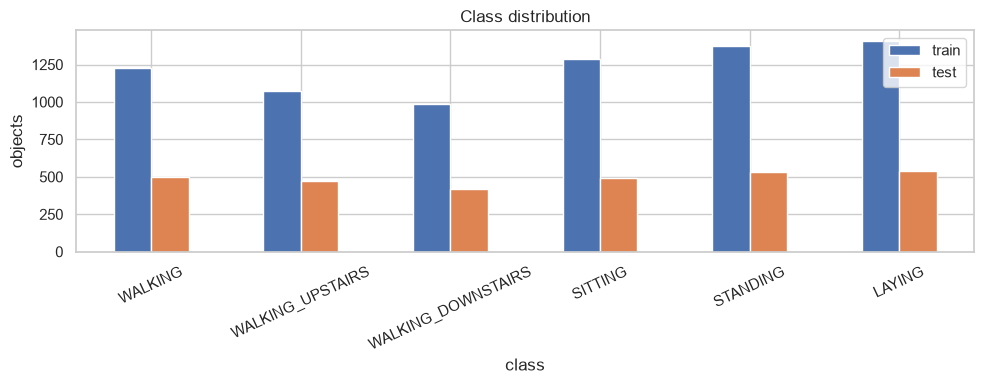

In [6]:
class_counts.set_index("class").plot(kind="bar", figsize=(10, 4))
plt.title("Class distribution")
plt.ylabel("objects")
plt.xticks(rotation=25)
plt.tight_layout()
plt.savefig(ROOT / "figures/00_class_distribution.png", dpi=150)
plt.show()


Сильного дисбаланса не вижу: даже в train самый большой класс отличается от самого маленького примерно в `1.4` раза. Поэтому `accuracy` оставляю headline-метрикой для сравнения с HAR baseline. Для early stopping и основного сравнения моделей использую `macro F1`, дополнительно считаю `balanced accuracy` -- так отдельно контролирую качество по всем классам.


### Что вообще лежит в каналах


In [7]:
flat = X_train.transpose(1, 0, 2).reshape(len(SIGNALS), -1)
channel_stats = pd.DataFrame({
    "channel": SIGNALS,
    "mean": flat.mean(axis=1),
    "std": flat.std(axis=1),
    "min": flat.min(axis=1),
    "max": flat.max(axis=1),
})
channel_stats.round(4)


,channel,mean,std,min,max
0,body_acc_x,-0.0006,0.1948,-1.2322,1.2999
1,body_acc_y,-0.0003,0.1224,-1.3453,0.9760
2,body_acc_z,-0.0003,0.1069,-1.3647,1.0669
3,body_gyro_x,0.0005,0.4068,-4.7337,4.1555
4,body_gyro_y,-0.0008,0.3819,-5.9743,5.7461
5,body_gyro_z,0.0001,0.2557,-2.7630,2.3660
6,total_acc_x,0.8047,0.4141,-0.4666,2.1976
7,total_acc_y,0.0288,0.3910,-1.5821,1.2174
8,total_acc_z,0.0865,0.3578,-1.6396,1.2814


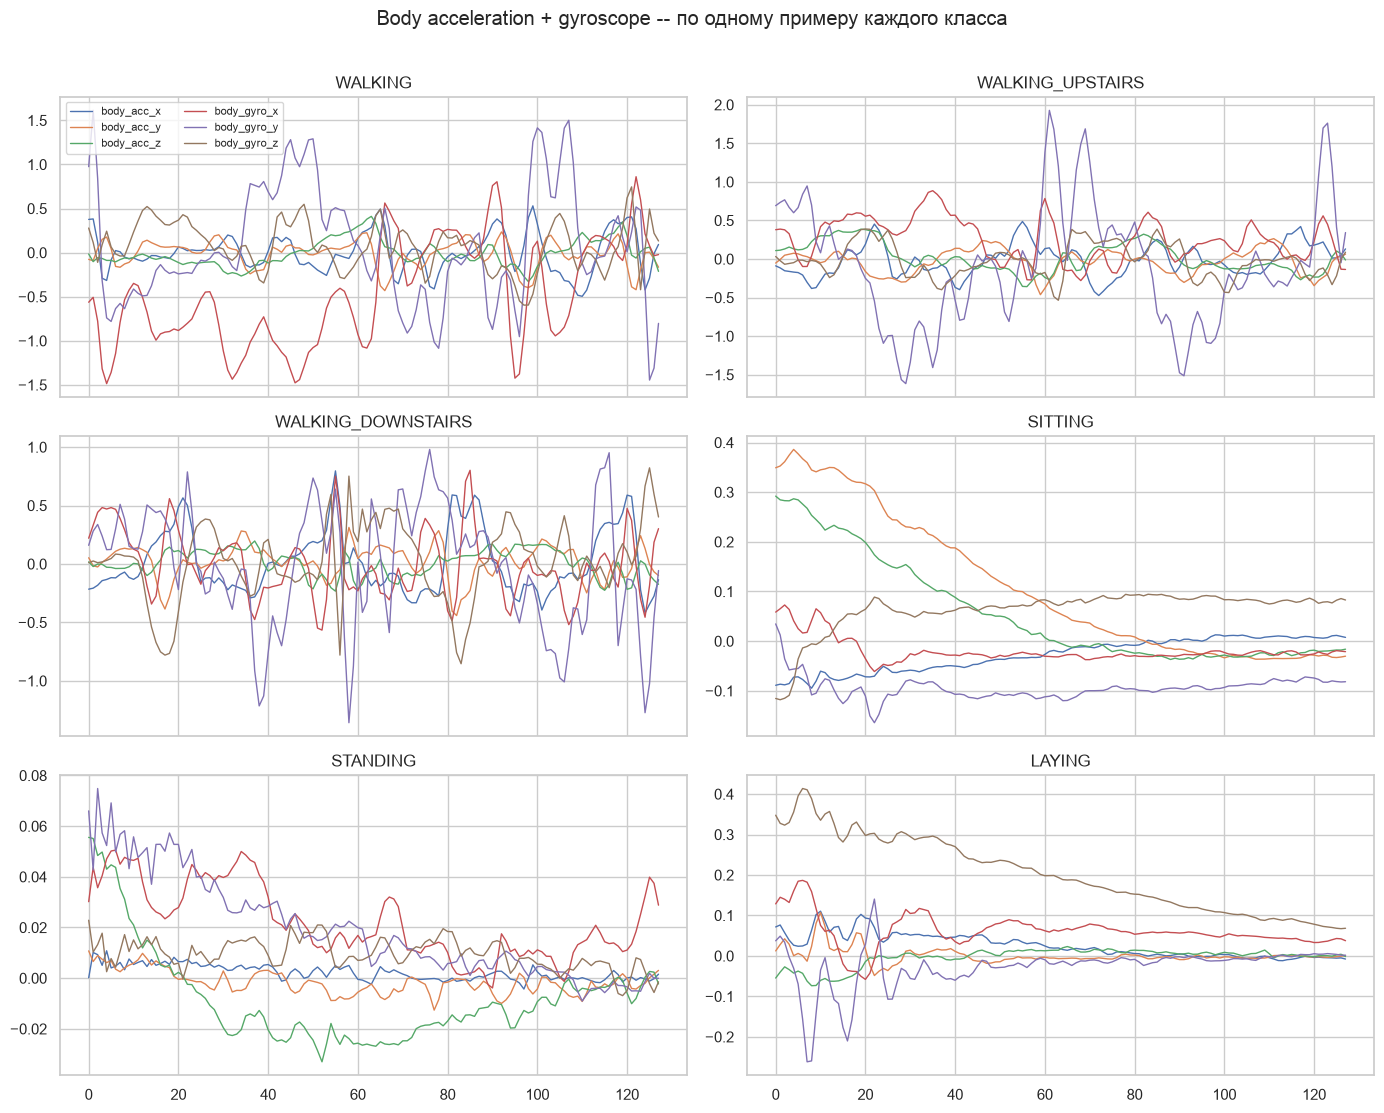

In [8]:
fig, axes = plt.subplots(3, 2, figsize=(14, 11), sharex=True)
for class_id, ax in enumerate(axes.ravel()):
    idx = np.where(y_train == class_id)[0][0]
    for channel in range(6):
        ax.plot(X_train[idx, channel], linewidth=1, label=SIGNALS[channel])
    ax.set_title(CLASS_NAMES[class_id])

axes[0, 0].legend(ncol=2, fontsize=8)
fig.suptitle("Body acceleration + gyroscope -- по одному примеру каждого класса", y=1.01)
plt.tight_layout()
plt.savefig(ROOT / "figures/00_examples.png", dpi=150, bbox_inches="tight")
plt.show()


По примерам видно ожидаемое разделение: у `WALKING*` есть выраженные колебания, а `SITTING`, `STANDING`, `LAYING` намного спокойнее. Значит, одной энергии сигнала недостаточно -- для статических активностей придется использовать форму ряда и совместное поведение каналов.


### Межканальные связи

Это как раз то, ради чего корпус особенно удобен для EdgeMTSC -- каналы получены с одного устройства и физически связаны между собой.


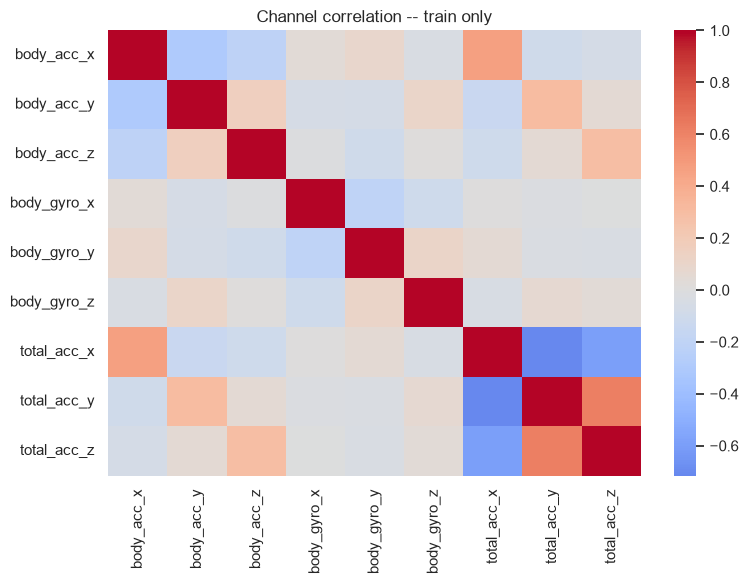

In [9]:
corr = np.corrcoef(flat)
plt.figure(figsize=(8, 6))
sns.heatmap(corr, xticklabels=SIGNALS, yticklabels=SIGNALS, cmap="coolwarm", center=0)
plt.title("Channel correlation -- train only")
plt.tight_layout()
plt.savefig(ROOT / "figures/00_channel_correlation.png", dpi=150)
plt.show()


По корреляциям связь каналов действительно есть. Самые заметные зависимости получаются между осями `total_acc`: примерно `-0.72` для `x/y`, `+0.62` для `y/z` и `-0.59` для `x/z`. Есть и связь `body_acc` с соответствующими `total_acc` осями. Для эксперимента с IMP это хороший сценарий -- межканальная информация тут не искусственная.


### Энергия сигналов и выбросы

Для временного ряда обычный boxplot по отдельным точкам мало что говорит. Смотрю RMS окна -- это простая характеристика общей энергии движения.


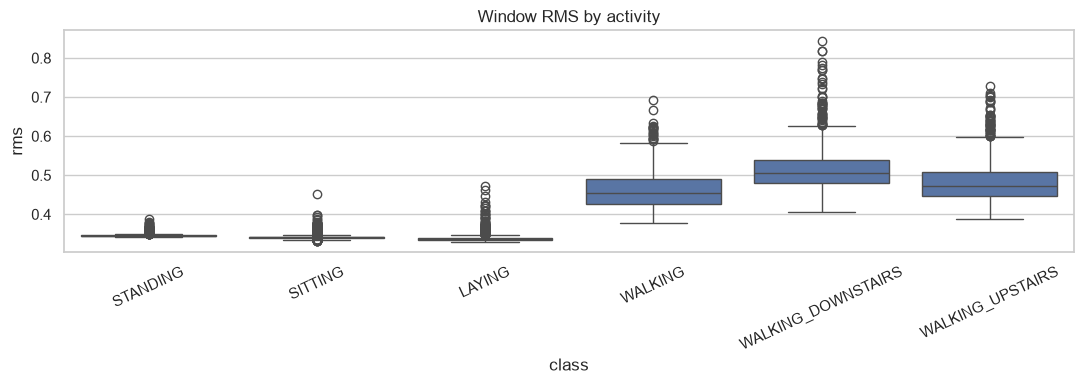

In [10]:
window_rms = np.sqrt(np.mean(X_train ** 2, axis=(1, 2)))
rms_df = pd.DataFrame({
    "rms": window_rms,
    "class": [CLASS_NAMES[i] for i in y_train],
})

plt.figure(figsize=(11, 4))
sns.boxplot(data=rms_df, x="class", y="rms")
plt.xticks(rotation=25)
plt.title("Window RMS by activity")
plt.tight_layout()
plt.savefig(ROOT / "figures/00_rms_by_class.png", dpi=150)
plt.show()


RMS хорошо отделяет динамические активности от статических, но внутри `WALKING*` распределения сильно пересекаются. Самая высокая энергия ожидаемо у `WALKING_DOWNSTAIRS`. Значит, RMS полезен для EDA, но сам по себе задачу не решает.


In [11]:
median = np.median(window_rms)
mad = np.median(np.abs(window_rms - median))
robust_z = 0.6745 * (window_rms - median) / mad

outliers = pd.DataFrame({
    "index": np.argsort(np.abs(robust_z))[-10:][::-1],
})
outliers["class"] = [CLASS_NAMES[y_train[i]] for i in outliers["index"]]
outliers["rms"] = window_rms[outliers["index"]]
outliers["robust_z"] = robust_z[outliers["index"]]
outliers


,index,class,rms,robust_z
0,3935,WALKING_DOWNSTAIRS,0.844750,22.087757
1,3934,WALKING_DOWNSTAIRS,0.818232,20.906864
2,3764,WALKING_DOWNSTAIRS,0.816808,20.843477
3,3954,WALKING_DOWNSTAIRS,0.789852,19.643061
4,3929,WALKING_DOWNSTAIRS,0.782949,19.335672
5,3930,WALKING_DOWNSTAIRS,0.775509,19.004362
6,3955,WALKING_DOWNSTAIRS,0.769476,18.735680
7,3936,WALKING_DOWNSTAIRS,0.768691,18.700724
8,3938,WALKING_DOWNSTAIRS,0.748536,17.803177
9,3958,WALKING_DOWNSTAIRS,0.746695,17.721224


Выбросы автоматически не удаляю. Самые большие robust-z почти полностью принадлежат `WALKING_DOWNSTAIRS`, то есть это не случайный мусор, а закономерно более энергичные окна. Если удалить их по одному порогу RMS, я скорее выкину сложные валидные примеры и сдвину train distribution.


### Двумерная проекция

Для общей картины посмотрю PCA по flattened окнам. Это не вход модели -- только EDA.


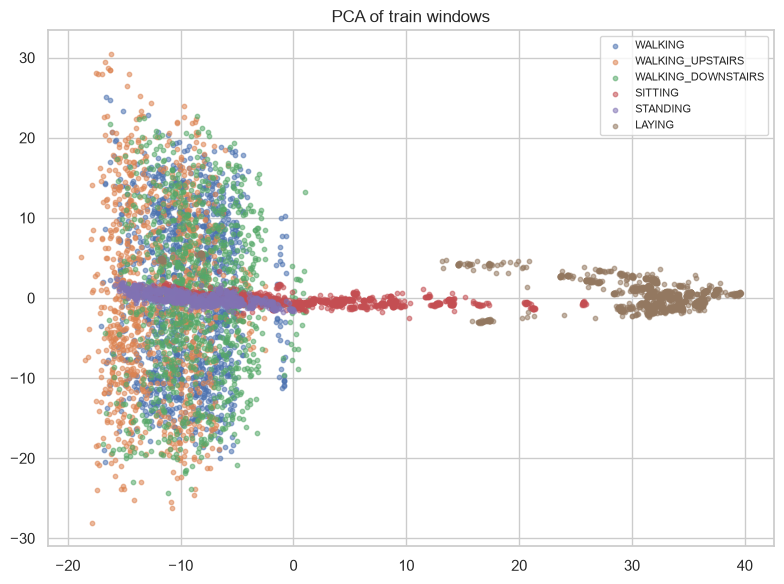

In [12]:
X_flat = X_train.reshape(len(X_train), -1)
X_pca = PCA(n_components=2, random_state=42).fit_transform(StandardScaler().fit_transform(X_flat))

plt.figure(figsize=(8, 6))
for class_id, name in enumerate(CLASS_NAMES):
    mask = y_train == class_id
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], s=10, alpha=0.55, label=name)
plt.legend(fontsize=8)
plt.title("PCA of train windows")
plt.tight_layout()
plt.savefig(ROOT / "figures/00_pca.png", dpi=150)
plt.show()


Первые две PCA-компоненты объясняют около `27.5%` дисперсии. На такой проекции часть классов расходится, но сильное пересечение остается -- особенно задача не сводится к простому линейному разделению flattened окон. Для DL-модели тут остается достаточно нетривиальной структуры.


### Сохраняю данные для следующих ноутбуков

Нормализацию здесь не делаю -- в CV `mean/std` должны считаться отдельно внутри каждого train fold, иначе получится leakage.


In [13]:
np.savez_compressed(
    ROOT / "data/uci_har_raw.npz",
    X_train=X_train,
    y_train=y_train,
    subjects_train=subjects_train,
    X_test=X_test,
    y_test=y_test,
    subjects_test=subjects_test,
)

print("saved:", ROOT / "data/uci_har_raw.npz")


saved: ../data/uci_har_raw.npz


Корпус подходит под задачу: данных достаточно для нормального DL-эксперимента, каналы физически связаны, а `128` временных шагов позволяют проверять разные receptive field. Обучаю все локально на ноуте, поэтому дальше держу модели примерно в одном умеренном parameter budget -- около `180k` параметров.

Дальше использую 3-fold `GroupKFold` по `subject_id` на official train. Test не участвует в fit scaler, CV, early stopping и выборе числа эпох.
